<a href="https://colab.research.google.com/github/kanchan745/Netflix-Data-Visualization-Matplotlib/blob/main/Netflix_data_visualisation_using__Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Goal - for better understanding  content of the Netflix
#example - What of type of contents (no.of shows , movies changes per year), which country producing the highest content ,how much ratings are spread (PG = parential guidance suggested) ,R - restricted , TV-MA (mature Audience) ,TV14 - parent strongly cautioned -intended for viewers aged14 or old etc
#rating or content rating = assigned to movie ,TV show , to show u can watch .
#movies =  to show - Top categories

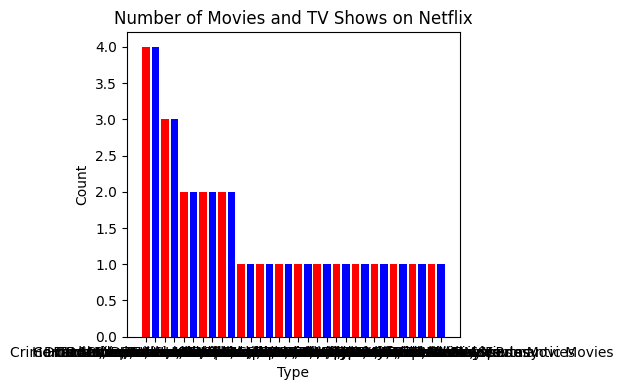

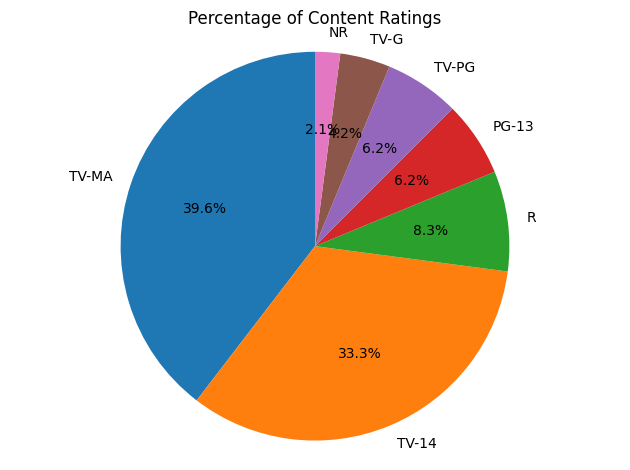

In [27]:
#import the libraries
import pandas as pd
import matplotlib.pyplot as plt
#data loading
df = pd.read_csv("/content/Netflix_Dataset.csv", engine='python')
df =df.head(50)

#cleaning data

df =df.dropna(subset = ["Type",'Release_Date',"Rating",'Country',"Duration"])
type_counts = df['Type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index,type_counts.values,color = ['red','Blue'])
plt.title("Number of Movies and TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
#plt.savefig("Movies_VS _TvShows.png")
plt.show()

# Define Rating_counts before using it
Rating_counts = df['Rating'].value_counts()

plt.pie(Rating_counts,labels = Rating_counts.index,autopct = "%1.1f%%", startangle=90)
plt.title("Percentage of Content Ratings")
plt.axis("equal")
plt.tight_layout()
#plt.savefig("Rating_Percentage.png")
plt.show()


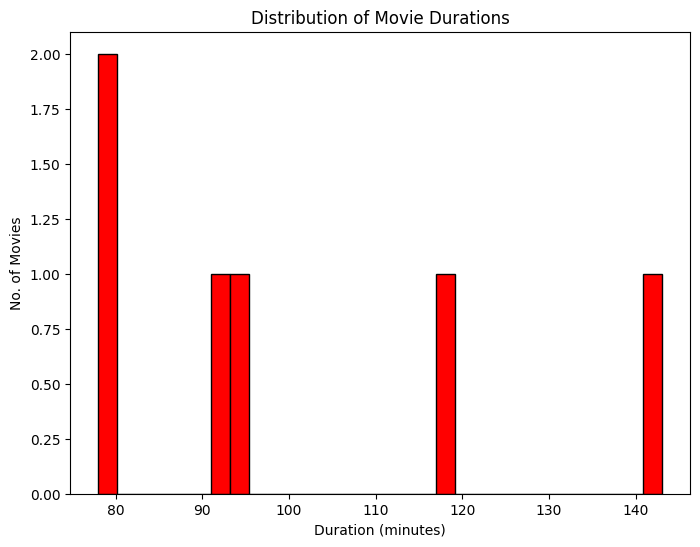

In [14]:
#Distribution of movies using histogram

Movie_df = df[df['Type'].str.contains("Movie", case=False, na=False)].copy()

# Check if Movie_df is empty before plotting
if Movie_df.empty:
    print("No movie data available to plot the distribution. Please ensure 'df' contains 'Movie' entries and is not truncated (e.g., using df.head()).")
else:
    Movie_df['Duration_int'] = Movie_df['Duration'].str.replace('min','').astype(int)
    plt.figure(figsize=(8,6))

    plt.hist(Movie_df['Duration_int'],bins = 30,color = 'red',edgecolor = 'black')
    plt.title('Distribution of Movie Durations')
    plt.xlabel('Duration (minutes)')
    plt.ylabel('No. of Movies')
    plt.show()


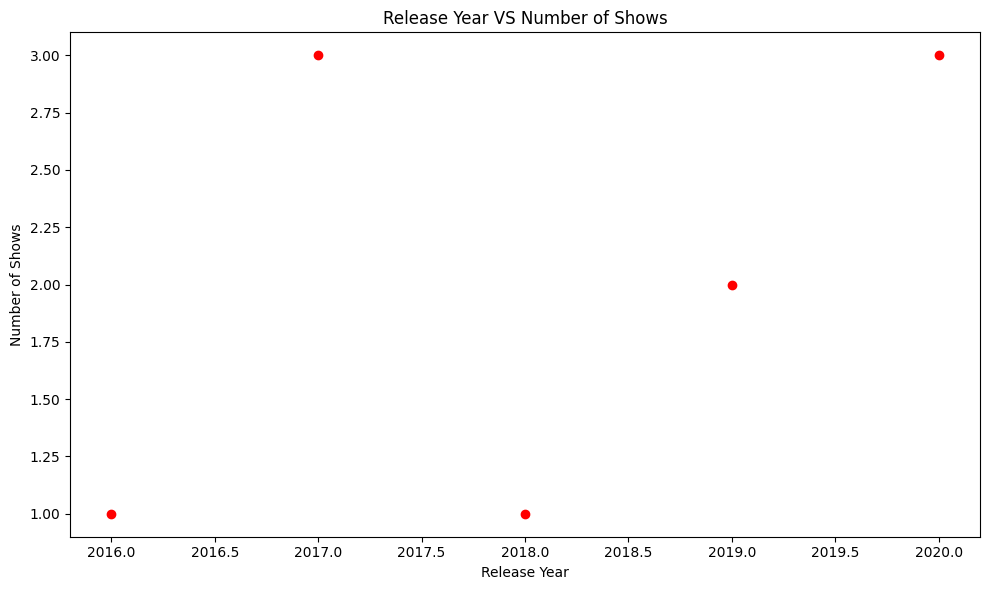

In [16]:
# Extract release year from 'Release_Date'
df['Release_Year'] = pd.to_datetime(df['Release_Date']).dt.year
release_counts = df['Release_Year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(release_counts.index, release_counts.values, color='red')
plt.title('Release Year VS Number of Shows')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows')
plt.tight_layout()
plt.savefig('release_year_Scatter.png')
plt.show()

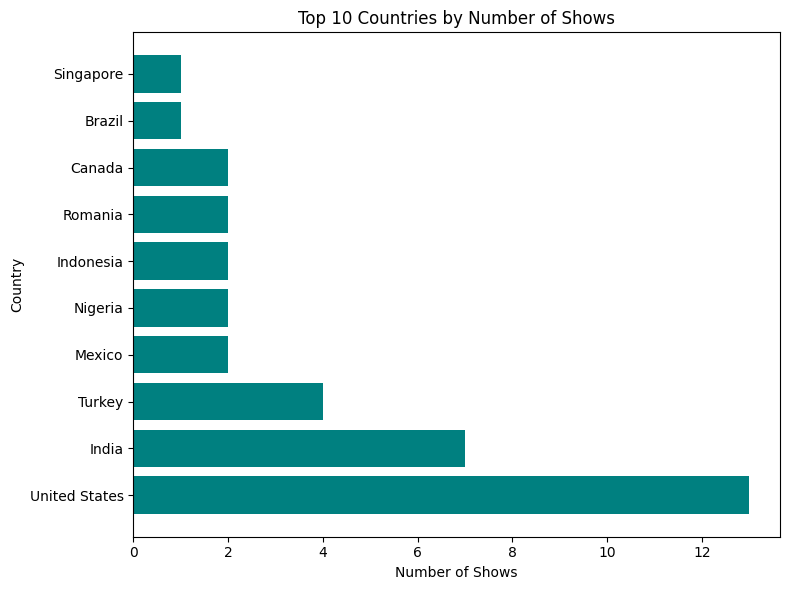

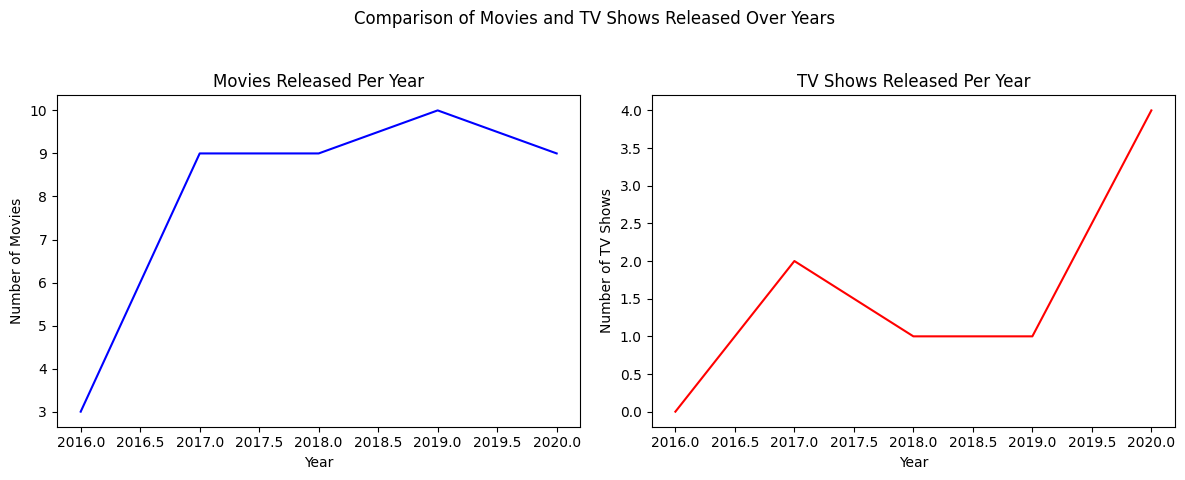

In [30]:
# Part 1: Top 10 Countries by Number of Shows

# Ensure 'Release_Year' is available for subsequent parts of the cell
df['Release_Year'] = pd.to_datetime(df['Release_Date']).dt.year

country_counts = df['Country'].value_counts().head(10)

plt.figure(figsize=(8,6))
plt.barh(country_counts.index, country_counts.values, color="teal")
plt.title('Top 10 Countries by Number of Shows')
plt.xlabel('Number of Shows')
plt.ylabel('Country')
plt.tight_layout()
#plt.savefig('top10_countries.png')
plt.show()

# Part 2: Comparison of Movies and TV Shows Released Over Years
# Ensure 'Type' is standardized (should be from bd3cb8e0)
content_by_year = df.groupby(['Release_Year', 'Category']).size().unstack().fillna(0)

fig, ax = plt.subplots(1,2, figsize=(12,5))

# First subplot: Movies

ax[0].plot(content_by_year.index, content_by_year["Movie"], color='blue')
ax[0].set_title('Movies Released Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')

# Second subplot: TV Shows
# Assuming 'TV Show' is the other type based on previous plots
if "TV Show" in content_by_year.columns:
    ax[1].plot(content_by_year.index, content_by_year["TV Show"], color='red')
    ax[1].set_title('TV Shows Released Per Year')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('Number of TV Shows')
else:
    print("No 'TV Show' data found in content_by_year for the second subplot.")

fig.suptitle('Comparison of Movies and TV Shows Released Over Years')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()